In [81]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [82]:
sber = pd.read_csv('data/SBRF.txt')

In [83]:
def good_dataframe(data, timeframe):
  """Преобразует сырые рыночные данные в чистый DataFrame с правильными типами и индексом времени
    
    Подготавливает данные для технического анализа.
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            ['<TICKER>', '<PER>', '<DATE>', '<TIME>', '<OPEN>', '<HIGH>', '<LOW>', '<CLOSE>', '<VOL>']
            
    Returns:
        tuple: Возвращает кортеж из двух DataFrame:
            - Основной DataFrame
            - Копия DataFrame для безопасного резервирования
            
    Processing Logic:
        1. Удаление избыточных столбцов
        2. Переименование столбцов в human-friendly формат
        3. Преобразование типов данных
        4. Создание правильного временного индекса
    """
  # 1. Удаляем ненужные столбцы (тикер и период не нужны для анализа)
  data.drop(['<TICKER>', '<PER>'], inplace=True, axis=1)
    
  # 2. Переименовываем столбцы для удобства работы
  data.columns = ['date', 'time', 'open', 'high', 'low', 'close', 'volume']
    
  # 3. Преобразуем дату из формата YYYYMMDD в datetime
  data['date'] = pd.to_datetime(data['date'], format='%Y%m%d')
    
  # 4. Обрабатываем время (HHMMSS -> datetime.time)
  data['time'] = pd.to_datetime(data['time'], format='%H%M%S').dt.time
    
  # 5. Комбинируем дату и время в единую метку времени
  data['time'] = pd.to_datetime(
        data['date'].astype('str') + ' ' + data['time'].astype('str'))
    
  # 6. Удаляем отдельный столбец даты (теперь он в индексе)
  data.drop(['date'], inplace=True, axis=1)
  
  # 7. Установка индекса
  data_final = data.set_index('time')
  
  
  
  def new_timeframe(data, timeframe):
    """Преобразует минутные данные (1М) в указанный временной интервал, сохраняя структуру OHLCV-данных.
    
    Использует принципы агрегации свечных данных:
    - Open - первое значение периода
    - High - максимум периода
    - Low - минимум периода
    - Close - последнее значение периода
    - Volume - сумма объема за период

    Args:
        data (pd.DataFrame): Исходный DataFrame с 1-минутными данными, 
                            должен содержать колонки ['open', 'high', 'low', 'close', 'volume']
                            и иметь DateTimeIndex
        timeframe (str): Желаемый таймфрейм из списка доступных:
                        ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']

    Returns:
        pd.DataFrame: Новый DataFrame с преобразованными данными в указанном таймфрейме
        
    Raises:
        ValueError: Если передан неподдерживаемый timeframe
    """
    dict_tf = {'5 min' : '5min', '15 min' : '15min', '30 min' : '30min',
               '1h' : '1h', '2h' : '2h', '4h' : '4h', 'D' : 'D'}

    return_data = data.resample(dict_tf[timeframe]).agg({
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum'
        }).dropna()
    
    return return_data
  
  result = new_timeframe(data_final, timeframe)
  
  return result


In [84]:
sber_15_bad = good_dataframe(sber, '15 min')
sber_15 = sber_15_bad.reset_index()
sber_15

,time,open,high,low,close,volume
0,2009-01-11 10:30:00,2301.0,2346.0,2265.0,2340.0,2993
1,2009-01-11 10:45:00,2341.0,2380.0,2340.0,2361.0,4804
2,2009-01-11 11:00:00,2366.0,2369.0,2352.0,2361.0,1660
3,2009-01-11 11:15:00,2360.0,2362.0,2324.0,2347.0,2811
4,2009-01-11 11:30:00,2343.0,2350.0,2338.0,2346.0,425
...,...,...,...,...,...,...
229931,2025-06-30 22:45:00,29853.0,29856.0,29834.0,29838.0,212
229932,2025-06-30 23:00:00,29837.0,29840.0,29825.0,29828.0,266
229933,2025-06-30 23:15:00,29827.0,29865.0,29827.0,29849.0,276
229934,2025-06-30 23:30:00,29849.0,29853.0,29845.0,29845.0,166


# Смещение данных

In [85]:
def shift_features_2_candle(data):
    data_c = data.copy()
    for i in ['open', 'close', 'low', 'high', 'volume', 'time']:
        data_c[f"{i}_N"] = data[i]
        data_c[f'{i}_N-1'] = data[i].shift(1)
    data_c.drop(['open', 'close', 'low', 'high', 'volume', 'time'], axis=1, inplace=True)
    data_c.dropna(inplace=True)
    for i in ['open', 'close', 'low', 'high', 'volume']:
        data_c[f'{i}_N-1'] = data_c[f'{i}_N-1'].astype('int32')
    return data_c

df = shift_features_2_candle(sber_15)
df

,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,time_N,time_N-1
1,2341.0,2301,2361.0,2340,2340.0,2265,2380.0,2346,4804,2993,2009-01-11 10:45:00,2009-01-11 10:30:00
2,2366.0,2341,2361.0,2361,2352.0,2340,2369.0,2380,1660,4804,2009-01-11 11:00:00,2009-01-11 10:45:00
3,2360.0,2366,2347.0,2361,2324.0,2352,2362.0,2369,2811,1660,2009-01-11 11:15:00,2009-01-11 11:00:00
4,2343.0,2360,2346.0,2347,2338.0,2324,2350.0,2362,425,2811,2009-01-11 11:30:00,2009-01-11 11:15:00
5,2346.0,2343,2346.0,2346,2344.0,2338,2355.0,2350,773,425,2009-01-11 11:45:00,2009-01-11 11:30:00
...,...,...,...,...,...,...,...,...,...,...,...,...
229931,29853.0,29864,29838.0,29845,29834.0,29845,29856.0,29868,212,224,2025-06-30 22:45:00,2025-06-30 22:30:00
229932,29837.0,29853,29828.0,29838,29825.0,29834,29840.0,29856,266,212,2025-06-30 23:00:00,2025-06-30 22:45:00
229933,29827.0,29837,29849.0,29828,29827.0,29825,29865.0,29840,276,266,2025-06-30 23:15:00,2025-06-30 23:00:00
229934,29849.0,29827,29845.0,29849,29845.0,29827,29853.0,29865,166,276,2025-06-30 23:30:00,2025-06-30 23:15:00


# Напишем функцию детекции свечного паттерна

In [86]:
def detection_bullish_engulfing_pattern(data, filtr='NO'):
    """
    Функция для детекции бычьего паттерна 'поглощение' (Bullish Engulfing) на ценовых данных.
    Функция позволяет применять дополнительные фильтры для подтверждения надежности паттерна."""

    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'bullish_engulfing_pattern'
    
    # Векторизованные вычисления
    close_N = data['close_N']
    close_N_1 = data['close_N-1']
    open_N = data['open_N']
    open_N_1 = data['open_N-1']
    
    body_N = data['close_N'] - data['open_N']
    body_N_1 = data['close_N-1'] - data['open_N-1']
    
    # Базовое условие бычьего поглощения
    base_condition = (
        (body_N_1 < 0) & 
        (body_N > 0) &
        (open_N_1 < close_N) & 
        (close_N_1 > open_N)
    )
    
    if filtr == 'NO':
        # Отмечаем 2 свечи паттерна
        pattern_mask = base_condition
        data.loc[pattern_mask, 'pattern'] = 1
        # Сигнал - следующая свеча после завершения паттерна
        data.loc[pattern_mask.shift(1).fillna(False), 'signal'] = 1
    data['filtr'] = filtr
    return data

In [87]:
df_b = detection_bullish_engulfing_pattern(df)

In [88]:
df_b.head(30)

,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,time_N,time_N-1,pattern,signal,strategy,filtr
1,2341.0,2301,2361.0,2340,2340.0,2265,2380.0,2346,4804,2993,2009-01-11 10:45:00,2009-01-11 10:30:00,0,0,bullish_engulfing_pattern,NO
2,2366.0,2341,2361.0,2361,2352.0,2340,2369.0,2380,1660,4804,2009-01-11 11:00:00,2009-01-11 10:45:00,0,0,bullish_engulfing_pattern,NO
3,2360.0,2366,2347.0,2361,2324.0,2352,2362.0,2369,2811,1660,2009-01-11 11:15:00,2009-01-11 11:00:00,0,0,bullish_engulfing_pattern,NO
4,2343.0,2360,2346.0,2347,2338.0,2324,2350.0,2362,425,2811,2009-01-11 11:30:00,2009-01-11 11:15:00,0,0,bullish_engulfing_pattern,NO
5,2346.0,2343,2346.0,2346,2344.0,2338,2355.0,2350,773,425,2009-01-11 11:45:00,2009-01-11 11:30:00,0,0,bullish_engulfing_pattern,NO
6,2346.0,2346,2350.0,2346,2339.0,2344,2352.0,2355,901,773,2009-01-11 12:00:00,2009-01-11 11:45:00,0,0,bullish_engulfing_pattern,NO
7,2350.0,2346,2339.0,2350,2339.0,2339,2354.0,2352,519,901,2009-01-11 12:15:00,2009-01-11 12:00:00,0,0,bullish_engulfing_pattern,NO
8,2340.0,2350,2340.0,2339,2337.0,2339,2344.0,2354,270,519,2009-01-11 12:30:00,2009-01-11 12:15:00,0,0,bullish_engulfing_pattern,NO
9,2338.0,2340,2339.0,2340,2328.0,2337,2340.0,2344,574,270,2009-01-11 12:45:00,2009-01-11 12:30:00,0,0,bullish_engulfing_pattern,NO
10,2335.0,2338,2339.0,2339,2330.0,2328,2340.0,2340,396,574,2009-01-11 13:00:00,2009-01-11 12:45:00,0,0,bullish_engulfing_pattern,NO


Напишем функцию, которая считает прибыль или убыток при входе на цене открытия после завершения паттерна, держит позицию N следующих свечей, где N пробегает [1, 2, ..., 10, 15, 20, ..., 50] и выходит на закрытии последней свечи.

In [89]:
N = 1
df['open_NEW'] = df['open_N'].shift(-N)
df

,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,time_N,time_N-1,open_NEW
1,2341.0,2301,2361.0,2340,2340.0,2265,2380.0,2346,4804,2993,2009-01-11 10:45:00,2009-01-11 10:30:00,2366.0
2,2366.0,2341,2361.0,2361,2352.0,2340,2369.0,2380,1660,4804,2009-01-11 11:00:00,2009-01-11 10:45:00,2360.0
3,2360.0,2366,2347.0,2361,2324.0,2352,2362.0,2369,2811,1660,2009-01-11 11:15:00,2009-01-11 11:00:00,2343.0
4,2343.0,2360,2346.0,2347,2338.0,2324,2350.0,2362,425,2811,2009-01-11 11:30:00,2009-01-11 11:15:00,2346.0
5,2346.0,2343,2346.0,2346,2344.0,2338,2355.0,2350,773,425,2009-01-11 11:45:00,2009-01-11 11:30:00,2346.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
229931,29853.0,29864,29838.0,29845,29834.0,29845,29856.0,29868,212,224,2025-06-30 22:45:00,2025-06-30 22:30:00,29837.0
229932,29837.0,29853,29828.0,29838,29825.0,29834,29840.0,29856,266,212,2025-06-30 23:00:00,2025-06-30 22:45:00,29827.0
229933,29827.0,29837,29849.0,29828,29827.0,29825,29865.0,29840,276,266,2025-06-30 23:15:00,2025-06-30 23:00:00,29849.0
229934,29849.0,29827,29845.0,29849,29845.0,29827,29853.0,29865,166,276,2025-06-30 23:30:00,2025-06-30 23:15:00,29843.0


In [90]:
def lst_trade_statistics_bul(data, commission=0.001):
   # Удалим сперва все отметки паттерна и сигнала с последних 51 строки
   data.loc[len(data) - 51 : len(data), ['pattern', 'signal']] = 0
   # Проходимся циклом по периодам удержания позиции
   all_strategy = []
   for N in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45, 50]:
      strategy = [] # Список для результатов стратегии
      # Блок для определения цены входа и выхода
      exit_candidate = data['open_N'].shift(-N)
      is_entry = data['signal'] == 1
      entry_price = data['open_N'][is_entry]
      exit_price = exit_candidate[is_entry]
      # Считаем результат
      profit = exit_price - entry_price
      if len(profit) == 0:
         strategy_name = data['strategy'][1]
         filtr = data['filtr'][1]
         all_strategy.append({'strategy' : strategy_name, 'filtr' : filtr, 'N': N, 'trades': 0, 'win_rate': 0.0, 'total_profit': 0.0, 'results': 0})
         continue
      # Чистая прибыль
      profit_net = np.where(profit >= 0, profit * (1 - commission), profit * (1 + commission))
      # Статистика
      # Названия
      strategy_name = data['strategy'][1]
      filtr = data['filtr'][1]
      
      all_strategy.append({'strategy' : strategy_name, 'filtr' : filtr,
                           'N' : N,
                           'trades' : len(profit_net),
                           'win_rate' : np.round(np.mean(profit_net > 0), 2),
                           'total_profit' : np.round(np.sum(profit_net), 1),
                           'results' : profit_net})
   return all_strategy

result = lst_trade_statistics_bul(df_b)
result_strategy = pd.DataFrame(result)
result_strategy

,strategy,filtr,N,trades,win_rate,total_profit,results
0,bullish_engulfing_pattern,NO,1,7634,0.47,363.7,"[0.0, -2.002, -3.0029999999999997, 11.988, -13..."
1,bullish_engulfing_pattern,NO,2,7634,0.48,-4941.3,"[-3.0029999999999997, -11.011, -14.014, 18.981..."
2,bullish_engulfing_pattern,NO,3,7634,0.49,-3092.8,"[-12.011999999999999, -10.009999999999998, 0.9..."
3,bullish_engulfing_pattern,NO,4,7634,0.49,-2615.8,"[-14.014, 5.994, 12.987, 5.994, -26.0259999999..."
4,bullish_engulfing_pattern,NO,5,7634,0.49,5135.6,"[-11.011, 4.995, 19.98, 2.997, -34.034, 27.972..."
5,bullish_engulfing_pattern,NO,6,7634,0.50,4980.1,"[-16.016, -3.0029999999999997, 14.985, 15.984,..."
6,bullish_engulfing_pattern,NO,7,7634,0.50,3608.0,"[-15.014999999999999, -4.004, 6.993, 2.997, -4..."
7,bullish_engulfing_pattern,NO,8,7634,0.50,1172.2,"[-11.011, -4.004, 3.996, 5.994, -45.0449999999..."
8,bullish_engulfing_pattern,NO,9,7634,0.51,1340.3,"[-18.017999999999997, -14.014, 16.983, -11.011..."
9,bullish_engulfing_pattern,NO,10,7634,0.51,8642.9,"[-14.014, -16.016, 3.996, -10.009999999999998,..."


In [91]:
# соединим результаты торгов и датасет
profit_N_10 = result_strategy.loc[2, 'results']


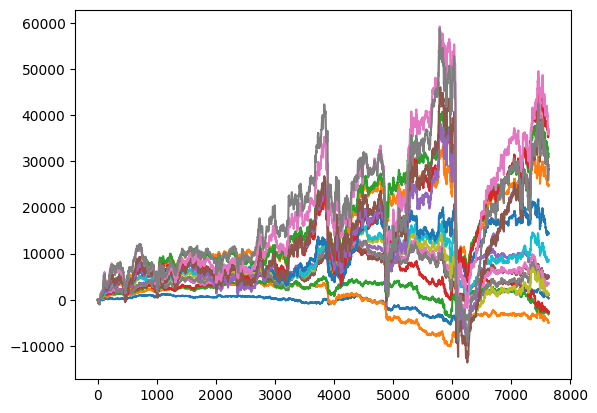

In [92]:
import seaborn as sns
for i in range(0, 18):
    profit_N_10 = result_strategy.loc[i, 'results']
    cumsume = np.cumsum(profit_N_10)
    sns.lineplot(cumsume)

In [93]:
df_b['profit'] = 0
profit_N_3 = result_strategy.loc[9, 'results']
df_b.loc[df_b['pattern'] == 1, 'profit'] = profit_N_10

Теперь нам необходимо создать признаки для модели классификации

In [94]:
df_b.info()

<class 'pandas.core.frame.DataFrame'>
Index: 229935 entries, 1 to 229935
Data columns (total 17 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   open_N      229935 non-null  float64       
 1   open_N-1    229935 non-null  int32         
 2   close_N     229935 non-null  float64       
 3   close_N-1   229935 non-null  int32         
 4   low_N       229935 non-null  float64       
 5   low_N-1     229935 non-null  int32         
 6   high_N      229935 non-null  float64       
 7   high_N-1    229935 non-null  int32         
 8   volume_N    229935 non-null  int64         
 9   volume_N-1  229935 non-null  int32         
 10  time_N      229935 non-null  datetime64[ns]
 11  time_N-1    229935 non-null  datetime64[ns]
 12  pattern     229935 non-null  int64         
 13  signal      229935 non-null  int64         
 14  strategy    229935 non-null  object        
 15  filtr       229935 non-null  object        
 16  profit 

In [95]:
df_b

,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,time_N,time_N-1,pattern,signal,strategy,filtr,profit
1,2341.0,2301,2361.0,2340,2340.0,2265,2380.0,2346,4804,2993,2009-01-11 10:45:00,2009-01-11 10:30:00,0,0,bullish_engulfing_pattern,NO,0.0
2,2366.0,2341,2361.0,2361,2352.0,2340,2369.0,2380,1660,4804,2009-01-11 11:00:00,2009-01-11 10:45:00,0,0,bullish_engulfing_pattern,NO,0.0
3,2360.0,2366,2347.0,2361,2324.0,2352,2362.0,2369,2811,1660,2009-01-11 11:15:00,2009-01-11 11:00:00,0,0,bullish_engulfing_pattern,NO,0.0
4,2343.0,2360,2346.0,2347,2338.0,2324,2350.0,2362,425,2811,2009-01-11 11:30:00,2009-01-11 11:15:00,0,0,bullish_engulfing_pattern,NO,0.0
5,2346.0,2343,2346.0,2346,2344.0,2338,2355.0,2350,773,425,2009-01-11 11:45:00,2009-01-11 11:30:00,0,0,bullish_engulfing_pattern,NO,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229931,29853.0,29864,29838.0,29845,29834.0,29845,29856.0,29868,212,224,2025-06-30 22:45:00,2025-06-30 22:30:00,0,0,bullish_engulfing_pattern,NO,0.0
229932,29837.0,29853,29828.0,29838,29825.0,29834,29840.0,29856,266,212,2025-06-30 23:00:00,2025-06-30 22:45:00,0,0,bullish_engulfing_pattern,NO,0.0
229933,29827.0,29837,29849.0,29828,29827.0,29825,29865.0,29840,276,266,2025-06-30 23:15:00,2025-06-30 23:00:00,0,0,bullish_engulfing_pattern,NO,0.0
229934,29849.0,29827,29845.0,29849,29845.0,29827,29853.0,29865,166,276,2025-06-30 23:30:00,2025-06-30 23:15:00,0,0,bullish_engulfing_pattern,NO,0.0


In [96]:
df_b

,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,time_N,time_N-1,pattern,signal,strategy,filtr,profit
1,2341.0,2301,2361.0,2340,2340.0,2265,2380.0,2346,4804,2993,2009-01-11 10:45:00,2009-01-11 10:30:00,0,0,bullish_engulfing_pattern,NO,0.0
2,2366.0,2341,2361.0,2361,2352.0,2340,2369.0,2380,1660,4804,2009-01-11 11:00:00,2009-01-11 10:45:00,0,0,bullish_engulfing_pattern,NO,0.0
3,2360.0,2366,2347.0,2361,2324.0,2352,2362.0,2369,2811,1660,2009-01-11 11:15:00,2009-01-11 11:00:00,0,0,bullish_engulfing_pattern,NO,0.0
4,2343.0,2360,2346.0,2347,2338.0,2324,2350.0,2362,425,2811,2009-01-11 11:30:00,2009-01-11 11:15:00,0,0,bullish_engulfing_pattern,NO,0.0
5,2346.0,2343,2346.0,2346,2344.0,2338,2355.0,2350,773,425,2009-01-11 11:45:00,2009-01-11 11:30:00,0,0,bullish_engulfing_pattern,NO,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229931,29853.0,29864,29838.0,29845,29834.0,29845,29856.0,29868,212,224,2025-06-30 22:45:00,2025-06-30 22:30:00,0,0,bullish_engulfing_pattern,NO,0.0
229932,29837.0,29853,29828.0,29838,29825.0,29834,29840.0,29856,266,212,2025-06-30 23:00:00,2025-06-30 22:45:00,0,0,bullish_engulfing_pattern,NO,0.0
229933,29827.0,29837,29849.0,29828,29827.0,29825,29865.0,29840,276,266,2025-06-30 23:15:00,2025-06-30 23:00:00,0,0,bullish_engulfing_pattern,NO,0.0
229934,29849.0,29827,29845.0,29849,29845.0,29827,29853.0,29865,166,276,2025-06-30 23:30:00,2025-06-30 23:15:00,0,0,bullish_engulfing_pattern,NO,0.0


# Создадим много относительных признаков

In [97]:
# Признаки по дате и времени
def data_time_features(data):
    # Для текущей свечи
    data = data.copy()
    data['time_N'] = pd.to_datetime(data['time_N'])
    data['months_N'] = data['time_N'].dt.month
    data['days_N'] = data['time_N'].dt.day
    data['hours_N'] = data['time_N'].dt.hour
    
    # Для предыдущей свечи
    data['time_N-1'] = pd.to_datetime(data['time_N-1'])
    data['months_N-1'] = data['time_N-1'].dt.month
    data['days_N-1'] = data['time_N-1'].dt.day
    data['hours_N-1'] = data['time_N-1'].dt.hour
    
    return data

In [98]:
# Признаки по каждой свече
def data_one_candle_features_1(data):
    # Для текущей свечи
    data = data.copy()
    
    # Отношение тела свечи ко всей свече
    body_N = np.abs(data['close_N'] - data['open_N'])
    body_N_1 = np.abs(data['close_N-1'] - data['open_N-1'])
    
    full_candle_N = np.abs(data['high_N'] - data['low_N'])
    full_candle_N_1 = np.abs(data['high_N-1'] - data['low_N-1'])
    
    data['ratio_body_to_all_candle_N'] = body_N / full_candle_N
    data['ratio_body_to_all_candle_N-1'] = body_N_1 / full_candle_N_1
    
    data = data.replace([np.inf], np.nan)
    data = data.fillna(1)
    
    # Отношение верхней тени к телу свечи
    up_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['high_N'] - data['close_N'], data['high_N'] - data['open_N'])
    up_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['high_N-1'] - data['close_N-1'], data['high_N-1'] - data['open_N-1'])
    
    data['ratio_up_shadow_to_body_N'] = up_shadow_N / body_N
    data['ratio_up_shadow_to_body_N-1'] = up_shadow_N_1 / body_N_1
    
    data = data.replace([np.inf], np.nan)
    data = data.fillna(-1)
    
    # Отношение нижней тени к телу свечи
    low_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['open_N'] - data['low_N'], data['close_N'] - data['low_N'])
    low_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['open_N-1'] - data['low_N-1'], data['close_N-1'] - data['low_N-1'])
    
    data['ratio_low_shadow_to_body_N'] = low_shadow_N / body_N
    data['ratio_low_shadow_to_body_N-1'] = low_shadow_N_1 / body_N_1
    
    data = data.replace([np.inf], np.nan)
    data = data.fillna(-1)
    
    # Отношение верхней тени к нижней тени
    data['ratio_up_shadow_to_low_shadow_N'] = up_shadow_N / low_shadow_N
    data['ratio_up_shadow_to_low_shadow_N-1'] = up_shadow_N_1 / low_shadow_N_1
    
    data = data.replace([np.inf], np.nan)
    data = data.fillna(-1)
    
    return data
    
    

In [99]:
def data_one_candle_features_2(data):
    data = data.copy()
    
    def ATR(data, period=14):
        high_low = data['high_N'] - data['low_N']
        high_close_prev = np.abs(data['high_N'] - data['close_N'].shift(1))
        low_close_prev = np.abs(data['low_N'] - data['close_N'].shift(1))
    
        TR = np.maximum(high_low, np.maximum(high_close_prev, low_close_prev))
        ATR = TR.rolling(period).mean()
    
        return ATR
    
    atr = ATR(data)
    
    data = data.copy()
    valid_mask = ~atr.isna()
    data = data[valid_mask]
    atr = atr[valid_mask]
    
    body_N = np.abs(data['close_N'] - data['open_N'])
    body_N_1 = np.abs(data['close_N-1'] - data['open_N-1'])
    
    full_candle_N = np.abs(data['high_N'] - data['low_N'])
    full_candle_N_1 = np.abs(data['high_N-1'] - data['low_N-1'])
    
    
    atr_safe = np.where(atr != 0, atr, 10e-8 )
    
    # Тело свечи / ATR
    data['body_ATR_N'] = body_N / atr_safe
    data['body_ATR_N-1'] = body_N_1 / atr_safe
    
    # Вся свеча / ATR
    data['full_candle_ATR_N'] = full_candle_N / atr_safe
    data['full_candle_ATR_N-1'] = full_candle_N_1 / atr_safe
    
    return data

In [100]:
df_full = data_time_features(df_b)
df_full = data_one_candle_features_1(df_full)
df_full = data_one_candle_features_2(df_full)
df_full

,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,...,ratio_up_shadow_to_body_N,ratio_up_shadow_to_body_N-1,ratio_low_shadow_to_body_N,ratio_low_shadow_to_body_N-1,ratio_up_shadow_to_low_shadow_N,ratio_up_shadow_to_low_shadow_N-1,body_ATR_N,body_ATR_N-1,full_candle_ATR_N,full_candle_ATR_N-1
15,2335.0,2339,2342.0,2337,2333.0,2337,2342.0,2340,46,111,...,0.000000,0.500000,0.285714,0.000000,0.000000,-1.000000,0.579882,0.165680,0.745562,0.248521
16,2337.0,2335,2337.0,2342,2334.0,2333,2342.0,2342,121,46,...,-1.000000,0.000000,-1.000000,0.285714,1.666667,0.000000,0.000000,0.612500,0.700000,0.787500
17,2337.0,2337,2334.0,2337,2334.0,2334,2337.0,2342,582,121,...,0.000000,-1.000000,0.000000,-1.000000,-1.000000,1.666667,0.336000,0.000000,0.336000,0.896000
18,2334.0,2337,2326.0,2334,2326.0,2334,2335.0,2337,370,582,...,0.125000,0.000000,0.000000,0.000000,-1.000000,-1.000000,0.918033,0.344262,1.032787,0.344262
19,2325.0,2334,2323.0,2326,2319.0,2326,2328.0,2335,534,370,...,1.500000,0.125000,2.000000,0.000000,0.750000,-1.000000,0.233333,0.933333,1.050000,1.050000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229931,29853.0,29864,29838.0,29845,29834.0,29845,29856.0,29868,212,224,...,0.200000,0.210526,0.266667,0.000000,0.750000,-1.000000,0.878661,1.112971,1.288703,1.347280
229932,29837.0,29853,29828.0,29838,29825.0,29834,29840.0,29856,266,212,...,0.333333,0.200000,0.333333,0.266667,1.000000,0.750000,0.545455,0.909091,0.909091,1.333333
229933,29827.0,29837,29849.0,29828,29827.0,29825,29865.0,29840,276,266,...,0.727273,0.333333,0.000000,0.333333,-1.000000,1.000000,1.283333,0.525000,2.216667,0.875000
229934,29849.0,29827,29845.0,29849,29845.0,29827,29853.0,29865,166,276,...,1.000000,0.727273,0.000000,0.000000,-1.000000,-1.000000,0.243478,1.339130,0.486957,2.313043


<Axes: ylabel='body_ATR_N-1'>

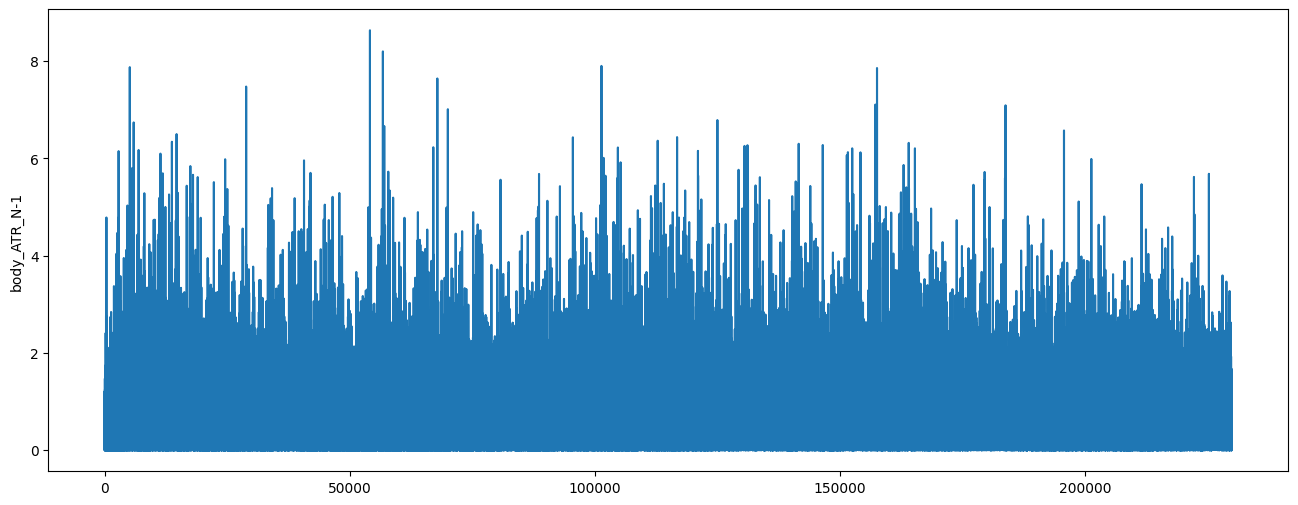

In [101]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16,6))
sns.lineplot(df_full['body_ATR_N-1'])

In [102]:
def last_prepare(data):
    data = data.copy()
    data.drop(['open_N', 'open_N-1', 'close_N', 'close_N-1', 'low_N', 'low_N-1',
       'high_N', 'high_N-1', 'volume_N', 'volume_N-1', 'time_N-1', 
       'signal', 'strategy', 'filtr'], axis=1, inplace=True)
    return data
df_ml = last_prepare(df_full)
df_ml

,time_N,pattern,profit,months_N,days_N,hours_N,months_N-1,days_N-1,hours_N-1,ratio_body_to_all_candle_N,...,ratio_up_shadow_to_body_N,ratio_up_shadow_to_body_N-1,ratio_low_shadow_to_body_N,ratio_low_shadow_to_body_N-1,ratio_up_shadow_to_low_shadow_N,ratio_up_shadow_to_low_shadow_N-1,body_ATR_N,body_ATR_N-1,full_candle_ATR_N,full_candle_ATR_N-1
15,2009-01-11 14:15:00,1,-12.012,1,11,14,1,11,14,0.777778,...,0.000000,0.500000,0.285714,0.000000,0.000000,-1.000000,0.579882,0.165680,0.745562,0.248521
16,2009-01-11 14:30:00,0,0.000,1,11,14,1,11,14,0.000000,...,-1.000000,0.000000,-1.000000,0.285714,1.666667,0.000000,0.000000,0.612500,0.700000,0.787500
17,2009-01-11 14:45:00,0,0.000,1,11,14,1,11,14,1.000000,...,0.000000,-1.000000,0.000000,-1.000000,-1.000000,1.666667,0.336000,0.000000,0.336000,0.896000
18,2009-01-11 15:00:00,0,0.000,1,11,15,1,11,14,0.888889,...,0.125000,0.000000,0.000000,0.000000,-1.000000,-1.000000,0.918033,0.344262,1.032787,0.344262
19,2009-01-11 15:15:00,0,0.000,1,11,15,1,11,15,0.222222,...,1.500000,0.125000,2.000000,0.000000,0.750000,-1.000000,0.233333,0.933333,1.050000,1.050000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229931,2025-06-30 22:45:00,0,0.000,6,30,22,6,30,22,0.681818,...,0.200000,0.210526,0.266667,0.000000,0.750000,-1.000000,0.878661,1.112971,1.288703,1.347280
229932,2025-06-30 23:00:00,0,0.000,6,30,23,6,30,22,0.600000,...,0.333333,0.200000,0.333333,0.266667,1.000000,0.750000,0.545455,0.909091,0.909091,1.333333
229933,2025-06-30 23:15:00,0,0.000,6,30,23,6,30,23,0.578947,...,0.727273,0.333333,0.000000,0.333333,-1.000000,1.000000,1.283333,0.525000,2.216667,0.875000
229934,2025-06-30 23:30:00,0,0.000,6,30,23,6,30,23,0.500000,...,1.000000,0.727273,0.000000,0.000000,-1.000000,-1.000000,0.243478,1.339130,0.486957,2.313043


In [103]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
Index: 229921 entries, 15 to 229935
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   time_N                             229921 non-null  datetime64[ns]
 1   pattern                            229921 non-null  int64         
 2   profit                             229921 non-null  float64       
 3   months_N                           229921 non-null  int32         
 4   days_N                             229921 non-null  int32         
 5   hours_N                            229921 non-null  int32         
 6   months_N-1                         229921 non-null  int32         
 7   days_N-1                           229921 non-null  int32         
 8   hours_N-1                          229921 non-null  int32         
 9   ratio_body_to_all_candle_N         229921 non-null  float64       
 10  ratio_body_to_all_candle

# Создаём целевую переменную

In [104]:
df_ml['target'] = np.where(df_ml['profit'] > 0, 1, 0)

In [105]:
df_ml = df_ml[df_ml['pattern'] == 1]
df_ml

,time_N,pattern,profit,months_N,days_N,hours_N,months_N-1,days_N-1,hours_N-1,ratio_body_to_all_candle_N,...,ratio_up_shadow_to_body_N-1,ratio_low_shadow_to_body_N,ratio_low_shadow_to_body_N-1,ratio_up_shadow_to_low_shadow_N,ratio_up_shadow_to_low_shadow_N-1,body_ATR_N,body_ATR_N-1,full_candle_ATR_N,full_candle_ATR_N-1,target
15,2009-01-11 14:15:00,1,-12.012,1,11,14,1,11,14,0.777778,...,0.500000,0.285714,0.000000,0.000000,-1.000000,0.579882,0.165680,0.745562,0.248521,0
55,2009-01-12 11:00:00,1,-41.041,1,12,11,1,12,10,0.916667,...,1.000000,0.090909,1.000000,0.000000,1.000000,1.140741,0.518519,1.244444,1.555556,0
153,2009-01-13 22:30:00,1,-131.131,1,13,22,1,13,22,1.000000,...,1.333333,0.000000,0.000000,-1.000000,-1.000000,1.348148,0.311111,1.348148,0.725926,0
156,2009-01-13 23:15:00,1,-124.124,1,13,23,1,13,23,0.850000,...,0.166667,0.000000,1.666667,-1.000000,0.100000,1.469136,0.518519,1.728395,1.469136,0
162,2009-01-14 11:15:00,1,-184.184,1,14,11,1,14,11,0.764706,...,2.000000,0.230769,6.000000,0.333333,0.333333,0.801762,0.123348,1.048458,1.110132,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229678,2025-06-24 19:30:00,1,271.728,6,24,19,6,24,19,0.704225,...,2.342857,0.320000,0.000000,0.312500,-1.000000,0.674374,0.472062,0.957611,1.578035,1
229769,2025-06-26 12:15:00,1,-8.008,6,26,12,6,26,12,0.363636,...,6.750000,0.800000,8.250000,1.187500,0.818182,0.369881,0.073976,1.017173,1.183620,0
229802,2025-06-26 20:30:00,1,151.848,6,26,20,6,26,20,0.708333,...,2.333333,0.000000,4.000000,-1.000000,0.583333,0.400673,0.070707,0.565657,0.518519,1
229824,2025-06-27 11:00:00,1,114.885,6,27,11,6,27,10,0.439394,...,9.000000,0.586207,14.000000,1.176471,0.642857,0.800789,0.027613,1.822485,0.662722,1


In [106]:
df_ml.drop(['profit', 'pattern'], axis=1, inplace=True)

In [107]:
df_ml

,time_N,months_N,days_N,hours_N,months_N-1,days_N-1,hours_N-1,ratio_body_to_all_candle_N,ratio_body_to_all_candle_N-1,ratio_up_shadow_to_body_N,ratio_up_shadow_to_body_N-1,ratio_low_shadow_to_body_N,ratio_low_shadow_to_body_N-1,ratio_up_shadow_to_low_shadow_N,ratio_up_shadow_to_low_shadow_N-1,body_ATR_N,body_ATR_N-1,full_candle_ATR_N,full_candle_ATR_N-1,target
15,2009-01-11 14:15:00,1,11,14,1,11,14,0.777778,0.666667,0.000000,0.500000,0.285714,0.000000,0.000000,-1.000000,0.579882,0.165680,0.745562,0.248521,0
55,2009-01-12 11:00:00,1,12,11,1,12,10,0.916667,0.333333,0.000000,1.000000,0.090909,1.000000,0.000000,1.000000,1.140741,0.518519,1.244444,1.555556,0
153,2009-01-13 22:30:00,1,13,22,1,13,22,1.000000,0.428571,0.000000,1.333333,0.000000,0.000000,-1.000000,-1.000000,1.348148,0.311111,1.348148,0.725926,0
156,2009-01-13 23:15:00,1,13,23,1,13,23,0.850000,0.352941,0.176471,0.166667,0.000000,1.666667,-1.000000,0.100000,1.469136,0.518519,1.728395,1.469136,0
162,2009-01-14 11:15:00,1,14,11,1,14,11,0.764706,0.111111,0.076923,2.000000,0.230769,6.000000,0.333333,0.333333,0.801762,0.123348,1.048458,1.110132,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229678,2025-06-24 19:30:00,6,24,19,6,24,19,0.704225,0.299145,0.100000,2.342857,0.320000,0.000000,0.312500,-1.000000,0.674374,0.472062,0.957611,1.578035,1
229769,2025-06-26 12:15:00,6,26,12,6,26,12,0.363636,0.062500,0.950000,6.750000,0.800000,8.250000,1.187500,0.818182,0.369881,0.073976,1.017173,1.183620,0
229802,2025-06-26 20:30:00,6,26,20,6,26,20,0.708333,0.136364,0.411765,2.333333,0.000000,4.000000,-1.000000,0.583333,0.400673,0.070707,0.565657,0.518519,1
229824,2025-06-27 11:00:00,6,27,11,6,27,10,0.439394,0.041667,0.689655,9.000000,0.586207,14.000000,1.176471,0.642857,0.800789,0.027613,1.822485,0.662722,1


# **Модель машинного обучения**

In [108]:
from sklearn.model_selection import train_test_split
from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.model_selection import StratifiedKFold

In [109]:
X = df_ml.drop('target', axis=1)
y = df_ml['target']

In [110]:
# Создаем маску по дате
date_mask = X['time_N'] < pd.to_datetime('2022-01-01 00:00:00')

# Разделяем и X и y
X_train = X[date_mask]
X_test = X[~date_mask]
y_train = y[date_mask] 
y_test = y[~date_mask]

In [111]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5947 entries, 15 to 181072
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   time_N                             5947 non-null   datetime64[ns]
 1   months_N                           5947 non-null   int32         
 2   days_N                             5947 non-null   int32         
 3   hours_N                            5947 non-null   int32         
 4   months_N-1                         5947 non-null   int32         
 5   days_N-1                           5947 non-null   int32         
 6   hours_N-1                          5947 non-null   int32         
 7   ratio_body_to_all_candle_N         5947 non-null   float64       
 8   ratio_body_to_all_candle_N-1       5947 non-null   float64       
 9   ratio_up_shadow_to_body_N          5947 non-null   float64       
 10  ratio_up_shadow_to_body_N-1        594

In [112]:
X_train.drop('time_N', axis=1, inplace=True)
X_test.drop('time_N', axis=1, inplace=True)

## 1. Модель логистической регрессии

Основные параметры LogisticRegression:

* random_state — число, на основе которого происходит генерация случайных чисел.
* penalty — метод регуляризации. Возможные значения:
    * 'l1' — L1-регуляризация;
    * 'l2' — L2-регуляризация (используется по умолчанию);
    * 'elasticnet' — эластичная сетка (L1+L2);
    * None — отсутствие регуляризации.
* C — коэффициент обратный коэффициенту регуляризации, то есть равен . Чем больше C, тем меньше регуляризация. По умолчанию C=1, тогда α=1.
* solver — численный метод оптимизации функции потерь logloss, может быть:
    * 'sag' — стохастический градиентный спуск (нужна стандартизация/нормализация);
    * 'saga' — [модификация](https://arxiv.org/pdf/1407.0202.pdf) предыдущего, которая поддерживает работу с негладкими функциями (нужна стандартизация/нормализация);
    * 'newton-cg' — [метод Ньютона с модификацией сопряжённых градиентов](https://docs.scipy.org/doc/scipy/tutorial/optimize.html#newton-conjugate-gradient-algorithm-method-newton-cg) (не нужна стандартизация/нормализация);
    * 'lbfgs' — [метод Бройдена — Флетчера — Гольдфарба — Шанно](https://ru.wikipedia.org/wiki/Алгоритм_Бройдена_—_Флетчера_—_Гольдфарба_—_Шанно) (не нужна стандартизация/нормализация; используется по умолчанию, так как из всех методов теоретически обеспечивает наилучшую сходимость);
    * 'liblinear' — [метод покоординатного спуска](http://www.machinelearning.ru/wiki/index.php?title=Метод_покоординатного_спуска) (не нужна стандартизация/нормализация).
* max_iter — максимальное количество итераций, выделенных на сходимость.

In [113]:
#Кросс-валидация
kf = model_selection.StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
# 
cv_metrcis = model_selection.cross_validate(
    estimator=LogisticRegression(),
    cv=kf,
    X=X_train,
    y=y_train,
    scoring=('f1', 'accuracy', 'recall', 'precision'))

# Смотрим результаты
print(f'Среднее значение F1-score на валидационных фолдах: {np.round(np.mean(cv_metrcis['test_f1']), 2)}')
print(f'Среднее значение accuracy на валидационных фолдах: {np.round(np.mean(cv_metrcis['test_accuracy']), 2)}')
print(f'Среднее значение recall на валидационных фолдах: {np.round(np.mean(cv_metrcis['test_recall']), 2)}')
print(f'Среднее значение precision на валидационных фолдах: {np.round(np.mean(cv_metrcis['test_precision']), 2)}')

# Расчитываем показатели на тестовой выборке 
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)

# Смотрим результаты
print(f'\nЗначение F1-score на тестовой выборке: {np.round(np.mean(metrics.f1_score(y_test, y_pred_log_reg)), 2)}')
print(f'Значение accuracy на тестовой выборке: {np.round(np.mean(metrics.accuracy_score(y_test, y_pred_log_reg)), 2)}')
print(f'Значение recall на тестовой выборке: {np.round(np.mean(metrics.recall_score(y_test, y_pred_log_reg)), 2)}')
print(f'Значение precision на тестовой выборке: {np.round(np.mean(metrics.precision_score(y_test, y_pred_log_reg)), 2)}')

Среднее значение F1-score на валидационных фолдах: 0.63
Среднее значение accuracy на валидационных фолдах: 0.51
Среднее значение recall на валидационных фолдах: 0.81
Среднее значение precision на валидационных фолдах: 0.52

Значение F1-score на тестовой выборке: 0.61
Значение accuracy на тестовой выборке: 0.51
Значение recall на тестовой выборке: 0.78
Значение precision на тестовой выборке: 0.51


In [114]:
from sklearn.model_selection import GridSearchCV

param_grid = [{'penalty' : ['l1'],
               'solver' : ['liblinear', 'saga'],
               'C' : [0.001, 0.01, 0.1, 1]},
              {'penalty': ['l2'],
               'solver' : ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
               'C' : [0.001, 0.01, 0.1, 1]}]

param_grid_log_reg = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=kf,
    n_jobs=-1,
    scoring=('f1'),
    return_train_score=True
)

param_grid_log_reg.fit(X_train, y_train)

,estimator,LogisticRegression()
,param_grid,"[{'C': [0.001, 0.01, ...], 'penalty': ['l1'], 'solver': ['liblinear', 'saga']}, {'C': [0.001, 0.01, ...], 'penalty': ['l2'], 'solver': ['newton-cg', 'lbfgs', ...]}]"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,penalty,'l1'


In [115]:
results_log_reg_gridsearch = pd.DataFrame(param_grid_log_reg.cv_results_)
best_index = param_grid_log_reg.best_index_

In [116]:
f1_score_train_G_S_1 = np.round(results_log_reg_gridsearch .loc[best_index, 'mean_train_score'], 3)
f1_score_test_G_S_1 = np.round(results_log_reg_gridsearch .loc[best_index, 'mean_test_score'], 3)
print(f'Среднее F1-score на валидационных фолдах лучшей модели: {f1_score_test_G_S_1}')
print(f'Наилучшие значения гиперпараметров: {param_grid_log_reg.best_params_}')
print(f'Значение F1-score на тестовой выборке: {np.round(param_grid_log_reg.score(X_test, y_test), 3)}')

Среднее F1-score на валидационных фолдах лучшей модели: 0.686
Наилучшие значения гиперпараметров: {'C': 0.001, 'penalty': 'l1', 'solver': 'liblinear'}
Значение F1-score на тестовой выборке: 0.661


Давайте перейдем к более мощным методам оптимизации

In [117]:
import optuna
from sklearn.model_selection import cross_val_score

def optuna_rf(trial):
    # Задаём пространство поиска гиперпараметров
    C = trial.suggest_float('C', 0.0001, 1, log=True)
    solver = trial.suggest_categorical('solver', ['liblinear', 'saga'])
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    
    # Модель логистической регрессии
    model = LogisticRegression(random_state=42, max_iter=5000, C=C, solver=solver, penalty=penalty)
    
    scores = cross_val_score(model, X=X_train, y=y_train, cv=kf, scoring='f1', n_jobs=-1)
    score = np.mean(scores)
    
    return score
    
    
study = optuna.create_study(study_name='LogisticRegression', direction='maximize')
study.optimize(optuna_rf, n_trials=20)

[I 2025-11-17 21:34:36,765] A new study created in memory with name: LogisticRegression
[I 2025-11-17 21:34:36,863] Trial 0 finished with value: 0.6858910324519686 and parameters: {'C': 0.0017585942501666585, 'solver': 'liblinear', 'penalty': 'l1'}. Best is trial 0 with value: 0.6858910324519686.
[I 2025-11-17 21:34:47,098] Trial 1 finished with value: 0.6389988614028799 and parameters: {'C': 0.3748849422764083, 'solver': 'saga', 'penalty': 'l1'}. Best is trial 0 with value: 0.6858910324519686.
[I 2025-11-17 21:34:47,197] Trial 2 finished with value: 0.6858910324519686 and parameters: {'C': 0.00021874499018622494, 'solver': 'saga', 'penalty': 'l1'}. Best is trial 0 with value: 0.6858910324519686.
[I 2025-11-17 21:34:47,295] Trial 3 finished with value: 0.6858910324519686 and parameters: {'C': 0.00045403291851824344, 'solver': 'saga', 'penalty': 'l1'}. Best is trial 0 with value: 0.6858910324519686.
[I 2025-11-17 21:34:47,616] Trial 4 finished with value: 0.6316140593861398 and paramete

ТЕперь деревья

In [118]:
from sklearn import ensemble

In [119]:
def optuna_rf(trial):
    # Задаём пространство поиска гиперпараметров
    n_estimators = trial.suggest_int('n_estimators', 100, 1000)     
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])  
    max_depth = trial.suggest_int('max_depth', 5, 25)                 
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 5, 25) 
    
    # Модель Случайного леса
    model = ensemble.RandomForestClassifier(random_state=42, n_estimators=n_estimators, criterion=criterion, max_depth=max_depth,
                                        min_samples_leaf=min_samples_leaf)
    
    scores = cross_val_score(model, X=X_train, y=y_train, cv=kf, scoring='f1', n_jobs=-1)
    score = np.mean(scores)
    
    return score

In [120]:
study = optuna.create_study(study_name='RandomForest', direction='maximize')
study.optimize(optuna_rf, n_trials=40)

[I 2025-11-17 21:35:15,319] A new study created in memory with name: RandomForest


[I 2025-11-17 21:35:23,137] Trial 0 finished with value: 0.5879792284265326 and parameters: {'n_estimators': 418, 'criterion': 'gini', 'max_depth': 21, 'min_samples_leaf': 25}. Best is trial 0 with value: 0.5879792284265326.
[I 2025-11-17 21:35:26,529] Trial 1 finished with value: 0.5738081750724014 and parameters: {'n_estimators': 146, 'criterion': 'gini', 'max_depth': 24, 'min_samples_leaf': 13}. Best is trial 0 with value: 0.5879792284265326.
[I 2025-11-17 21:35:35,620] Trial 2 finished with value: 0.5851116576449271 and parameters: {'n_estimators': 487, 'criterion': 'gini', 'max_depth': 22, 'min_samples_leaf': 22}. Best is trial 0 with value: 0.5879792284265326.
[I 2025-11-17 21:35:37,913] Trial 3 finished with value: 0.5773337040521832 and parameters: {'n_estimators': 111, 'criterion': 'gini', 'max_depth': 16, 'min_samples_leaf': 11}. Best is trial 0 with value: 0.5879792284265326.
[I 2025-11-17 21:35:43,261] Trial 4 finished with value: 0.5824896722231809 and parameters: {'n_esti

KeyboardInterrupt: 

In [126]:
log_reg = LogisticRegression(**{'C': 0.001, 'penalty': 'l1', 'solver': 'liblinear'})
log_reg.fit(X_train, y_train)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.001
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


0       0.505199
1       0.506759
2       0.508318
3       0.508838
4       0.511956
          ...   
1682    0.509877
1683    0.506239
1684    0.510397
1685    0.505199
1686    0.508838
Length: 1687, dtype: float64


<Axes: >

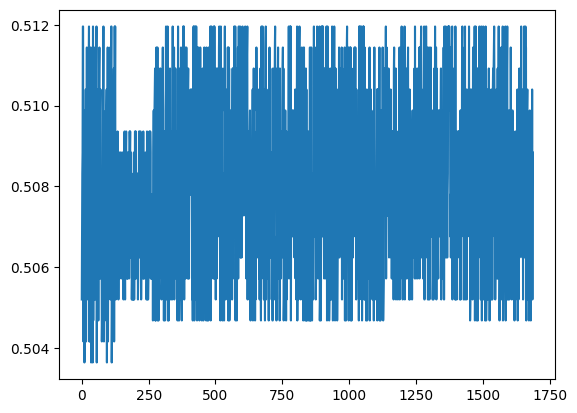

In [130]:
y_test_proba_pred = pd.Series(log_reg.predict_proba(X_test)[:, 1])
print(y_test_proba_pred)
sns.lineplot(y_test_proba_pred)

In [134]:
# Делаем предсказание вероятности оттока для каждого клиента из тестовой выборки
y_test_proba_pred = pd.Series(log_reg.predict_proba(X_test)[:, 1])
# Инициализируем список, куда будем сохранять метрики.
scores = []
# Дополнительные списки
precisions = []
recalls = []
# Задаём значения порогов вероятности
thresholds = np.arange(0.45, 0.55, 0.005)
# В цикле перебираем значения порогов вероятности
for threshold in thresholds:
    # Делаем предсказание
    y_test_pred_poly = y_test_proba_pred.apply(lambda x: 1 if x > threshold else 0)
    # Рассчитываем метрику
    score = metrics.f1_score(y_test, y_test_pred_poly)
    # Дополнительные метрики
    precision = metrics.precision_score(y_test, y_test_pred_poly)
    recall = metrics.recall_score(y_test, y_test_pred_poly)
    # Добавляем результат в список
    scores.append(score)
    precisions.append(precision)
    recalls.append(recall)
print(scores)
print(precisions)
print(recalls)

[0.6605795950774117, 0.6605795950774117, 0.6605795950774117, 0.6605795950774117, 0.6605795950774117, 0.6605795950774117, 0.6605795950774117, 0.6605795950774117, 0.6605795950774117, 0.6605795950774117, 0.6605795950774117, 0.6447860407145825, 0.2748735244519393, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.49318316538233553, 0.49318316538233553, 0.49318316538233553, 0.49318316538233553, 0.49318316538233553, 0.49318316538233553, 0.49318316538233553, 0.49318316538233553, 0.49318316538233553, 0.49318316538233553, 0.49318316538233553, 0.4926984126984127, 0.4604519774011299, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9326923076923077, 0.19591346153846154, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


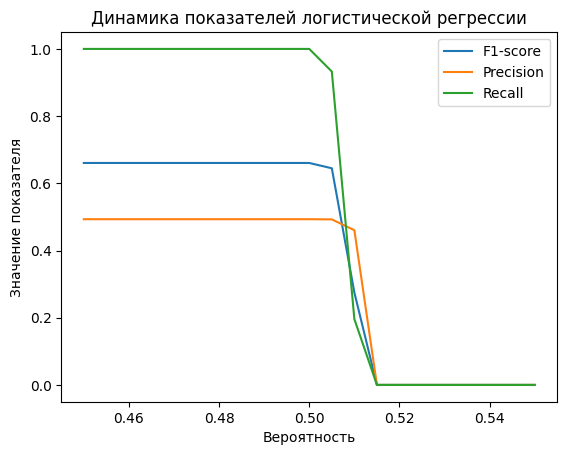

In [136]:
plt.title('Динамика показателей логистической регрессии')
sns.lineplot(x=np.arange(0.45, 0.55, 0.005), y=scores, label='F1-score')
sns.lineplot(x=np.arange(0.45, 0.55, 0.005), y=precisions, label='Precision')
sns.lineplot(x=np.arange(0.45, 0.55, 0.005), y=recalls, label='Recall')
plt.ylabel('Значение показателя')
plt.xlabel('Вероятность');